In [1]:
%%time
import sys, os
path_dir = os.getcwd()
sys.path.append(path_dir+"/Functions")
from Noise_functions import *
from PC_functions import *
from DCN_functions import *
from IO_functions import *
from Noise_PC_Synapses_functions import *
from PC_DCN_Synapses_functions import *
from DCN_IO_Synapses_functions import *
from IO_PC_Synapses_functions import *
from Other_synapses import *
from IO_Plots import *
from PC_Plots import *
from DCN_Plots import *
from Input_func import *
start_scope()
###################################################################
######################### Load Parameters #########################
###################################################################
Frozen_data = sio.loadmat('Data/'+datetime.datetime.now().strftime("%m-%d")+'/Frozen.mat', squeeze_me=True)
Params, Noise_frozen, Values, Synaps = Read_Input(Frozen_data)
###################################################################
######################## Initial Parameters #######################
###################################################################
dt = Params.dt
dt_rec = Params.dt_rec
width = Params.width
tau_noise = Params.tau_noise
exp_run = Params.exp_run
N_Noise = Params.N_Noise
N_Cells_PC = Params.N_Cells_PC
N_Cells_DCN = Params.N_Cells_DCN
N_Cells_IO = Params.N_Cells_IO
N_Copy = Params.N_Copy
N_Copy_order = Params.N_Copy_order
###################################################################
########################## Cell Values ############################
###################################################################
Noise_I = Noise_frozen.Noise_I
I_recorded = Noise_frozen.I_recorded
period = Noise_frozen.period
PC_Values = Values.PC_Values
DCN_Values = Values.DCN_Values
IO_Values = Values.IO_Values
IO_thresh = Values.IO_thresh
eqs_IO_syn = Values.eqs_IO_syn
rate_meas = Values.rate_meas
rate_meas_out = Values.rate_meas_out
tau_presyn = Values.tau_presyn
tau_thresh_M = Values.tau_thresh_M
sine_amplitude_presyn = Values.sine_amplitude_presyn
sine_frequency_presyn = Values.sine_frequency_presyn
eqs_syn_bcm_s_n_pc = Values.eqs_syn_bcm_s_n_pc
eqs_syn_IO_PC_pre = Values.eqs_syn_IO_PC_pre
###################################################################
###################### Synapses Values ############################
###################################################################
IO_Copy_Synapse_Targets = Synaps.IO_Copy_Synapse_Targets
Noise_PC_Synapse_Sources = Synaps.Noise_PC_Synapse_Sources
Noise_PC_Synapse_Targets = Synaps.Noise_PC_Synapse_Targets 
Noise_PC_Synapse_Weights = Synaps.Noise_PC_Synapse_Weights
PC_DCN_Synapse_Sources = Synaps.PC_DCN_Synapse_Sources
PC_DCN_Synapse_Targets = Synaps.PC_DCN_Synapse_Targets
DCN_IO_Synapse_Sources = Synaps.DCN_IO_Synapse_Sources 
DCN_IO_Synapse_Targets = Synaps.DCN_IO_Synapse_Targets 
IO_PC_Synapse_Sources = Synaps.IO_PC_Synapse_Sources
IO_PC_Synapse_Targets = Synaps.IO_PC_Synapse_Targets
###################################################################
###################################################################
############################## CELLS ##############################
###################################################################
###################################################################
############################## NOISE ##############################
###################################################################
Noise, Noise_statemon, Noise_extended, Noise_extended_statemon = Noise_neuron(N_Noise,I_recorded,period,dt,dt_rec)
###################################################################
########################## PURKINJE CELL ##########################
###################################################################
PC, PC_Statemon, PC_Spikemon, PC_rate = PC_neurons(N_Cells_PC,PC_Values,dt,dt_rec)
###################################################################
################## DEEP CEREBELLAR NUCLEI CELLS ###################
###################################################################
DCN, DCN_Statemon, DCN_Spikemon, DCN_rate = DCN_neurons(N_Cells_DCN,DCN_Values,dt,dt_rec)
###################################################################
############################# IO ##################################
###################################################################
IO, IO_Statemon, IO_Spikemon, IO_rate = IO_neurons(N_Cells_IO,IO_Values,IO_thresh,dt,dt_rec)
###################################################################
############################# PF ##################################
###################################################################
Input_presyn, Input_presyn_statemon = presyn_inp(N_Noise,sine_amplitude_presyn,sine_frequency_presyn, dt, dt_rec)
###################################################################
############################# Rate ################################
###################################################################
syn = rate_meas_func(rate_meas,PC,dt)
syn.connect(j='i')  
syn.subtract.delay = rate_meas_out  # delay the subtraction
###################################################################
############################# Copy ################################
###################################################################
conn_N_PC, mon_N_PC = conn_N_PC_func(N_Copy, Noise_PC_Synapse_Weights, dt, dt_rec)
###################################################################
###################################################################
############################## CELLS COUPLED ######################
###################################################################
###################################################################
############################## NOISE COUPLED ######################
###################################################################
Noise_Coupled, Noise_statemon_Coupled, Noise_extended_Coupled, Noise_extended_statemon_Coupled = Noise_neuron(N_Noise,I_recorded,period,dt,dt_rec)
###################################################################
########################## PURKINJE CELL COUPLED ##################
###################################################################
PC_Coupled, PC_Statemon_Coupled, PC_Spikemon_Coupled, PC_rate_Coupled = PC_neurons(N_Cells_PC,PC_Values,dt,dt_rec)
###################################################################
################ DEEP CEREBELLAR NUCLEI CELLS COUPLED #############
###################################################################
DCN_Coupled, DCN_Statemon_Coupled, DCN_Spikemon_Coupled, DCN_rate_Coupled = DCN_neurons(N_Cells_DCN,DCN_Values,dt,dt_rec)
###################################################################
############################# IO COUPLED ##########################
###################################################################
IO_Coupled, IO_Statemon_Coupled, IO_Spikemon_Coupled, IO_rate_Coupled = IO_neurons(N_Cells_IO,IO_Values,IO_thresh,dt,dt_rec)
IO_synapse_Coupled = IO_coup_syn(IO_Coupled,eqs_IO_syn) # create synaptic equations and apply full synaptic strength for second network
IO_synapse_Coupled.connect() # connect second network
###################################################################
############################# PF COUPLED ##########################
###################################################################
Input_presyn_Coupled, Input_presyn_statemon_Coupled = presyn_inp(N_Noise,sine_amplitude_presyn,sine_frequency_presyn, dt, dt_rec)
###################################################################
############################# Rate COUPLED ########################
###################################################################
syn_Coupled = rate_meas_func(rate_meas,PC_Coupled,dt)
syn_Coupled.connect(j='i')  
syn_Coupled.subtract.delay = rate_meas_out  # delay the subtraction 
###################################################################
############################# Copy COUPLED ########################
###################################################################
conn_N_PC_Coupled, mon_N_PC_Coupled = conn_N_PC_func(N_Copy, Noise_PC_Synapse_Weights, dt, dt_rec)

ld: warning: -pie being ignored. It is only used when linking a main executable
ld: unsupported tapi file type '!tapi-tbd' in YAML file '/Library/Developer/CommandLineTools/SDKs/MacOSX.sdk/usr/lib/libSystem.tbd' for architecture x86_64
clang-10: error: linker command failed with exit code 1 (use -v to see invocation)
WARNING    Cannot use Cython, a test compilation failed: command 'x86_64-apple-darwin13.4.0-clang++' failed with exit status 1 (LinkError) [brian2.codegen.runtime.cython_rt.cython_rt.failed_compile_test]
INFO       Cannot use compiled code, falling back to the numpy code generation target. Note that this will likely be slower than using compiled code. Set the code generation to numpy manually to avoid this message:
prefs.codegen.target = "numpy" [brian2.devices.device.codegen_fallback]


CPU times: user 2.3 s, sys: 426 ms, total: 2.72 s
Wall time: 4.89 s


In [2]:
###################################################################
###################################################################
########################## SYNAPSES ###############################
###################################################################
###################################################################
########################## PC DCN Synapse #########################
###################################################################
PC_DCN_Synapse = PC_DCN_syn(PC,DCN,N_Cells_PC,N_Cells_DCN,dt,dt_rec)
PC_DCN_Synapse.connect(i=PC_DCN_Synapse_Sources,j=PC_DCN_Synapse_Targets)
###################################################################
########################## DCN IO Synapse #########################
###################################################################
DCN_IO_Synapse = DCN_IO_syn(DCN,IO,N_Cells_DCN,N_Cells_IO,dt,dt_rec)
DCN_IO_Synapse.connect(i=DCN_IO_Synapse_Sources,j=DCN_IO_Synapse_Targets)
###################################################################
########################## IO ConnPC Synapse ######################
###################################################################
S_IO_N = Synapses(IO, conn_N_PC, method='euler',dt=dt)  # where f is 
S_IO_N.connect(i=IO_PC_Synapse_Sources, j=IO_Copy_Synapse_Targets)
###################################################################
########################### IO PC Synapse #########################
###################################################################
IO_PC_Synapse = Synapses(IO, PC, on_pre = eqs_syn_IO_PC_pre, delay=2*ms,method = 'euler',dt=dt)
IO_PC_Synapse.connect(i=IO_PC_Synapse_Sources,j=IO_PC_Synapse_Targets)
###################################################################
######################### ConnPC PC Synapse #######################
###################################################################
S_N_PC = Synapses(conn_N_PC,PC, eqs_syn_bcm_s_n_pc, method='euler',dt=dt)
S_N_PC.connect(i=N_Copy_order, j = Noise_PC_Synapse_Targets)
###################################################################
########################## ConnPC Noise Synapse ###################
###################################################################
S_PC_N = Synapses(conn_N_PC,Noise, 'weight_post = new_weight_pre : 1 (summed)', method='euler',dt=dt)
S_PC_N.connect(i=N_Copy_order, j = Noise_PC_Synapse_Sources)
###################################################################
############################# Copy rate ###########################
###################################################################
copy_rate = Synapses(Input_presyn, conn_N_PC, 'rho_PF_post = rho_presyn_pre : Hz (summed)', method='euler',dt=dt)
copy_rate.connect(i = Noise_PC_Synapse_Sources, j=N_Copy_order)
###################################################################
############################ Copy Noise ###########################
###################################################################
copy_noise = Synapses(Noise, conn_N_PC, 'I_post = I_pre : amp (summed)', method='euler', dt=dt)
copy_noise.connect(i = Noise_PC_Synapse_Sources, j=N_Copy_order)
copy_noise.weight = Noise_PC_Synapse_Weights
###################################################################
########################## PC Rate Synapse ########################
###################################################################
S_PC_rate = Synapses(PC,conn_N_PC, 'rho_PC_post = New_recent_rate_pre : Hz (summed)', method='euler',dt=dt)
S_PC_rate.connect(i=Noise_PC_Synapse_Targets, j =N_Copy_order)
###################################################################
###################################################################
####################### SYNAPSES COUPLED ##########################
###################################################################
###################################################################
########################## PC DCN Synapse #########################
###################################################################
PC_DCN_Synapse_Coupled = PC_DCN_syn(PC_Coupled,DCN_Coupled,N_Cells_PC,N_Cells_DCN,dt,dt_rec)
PC_DCN_Synapse_Coupled.connect(i=PC_DCN_Synapse_Sources,j=PC_DCN_Synapse_Targets)
###################################################################
#################### DCN IO Synapse COUPLED #######################
###################################################################
DCN_IO_Synapse_Coupled = DCN_IO_syn(DCN_Coupled,IO_Coupled,N_Cells_DCN,N_Cells_IO,dt,dt_rec)
DCN_IO_Synapse_Coupled.connect(i=DCN_IO_Synapse_Sources,j=DCN_IO_Synapse_Targets)
###################################################################
################# IO ConnPC Synapse COUPLED #######################
###################################################################
S_IO_N_Coupled = Synapses(IO_Coupled, conn_N_PC_Coupled, method='euler',dt=dt)  # where f is 
S_IO_N_Coupled.connect(i=IO_PC_Synapse_Sources, j=IO_Copy_Synapse_Targets)
###################################################################
##################### IO PC Synapse COUPLED #######################
###################################################################
IO_PC_Synapse_Coupled = Synapses(IO_Coupled, PC_Coupled, on_pre =eqs_syn_IO_PC_pre, delay=2*ms,method = 'euler',dt=dt)
IO_PC_Synapse_Coupled.connect(i=IO_PC_Synapse_Sources,j=IO_PC_Synapse_Targets)
###################################################################
################# ConnPC PC Synapse COUPLED #######################
###################################################################
S_N_PC_Coupled = Synapses(conn_N_PC_Coupled,PC_Coupled, eqs_syn_bcm_s_n_pc, method='euler',dt=dt)
S_N_PC_Coupled.connect(i=N_Copy_order, j = Noise_PC_Synapse_Targets)
###################################################################
############## ConnPC Noise Synapse COUPLED #######################
###################################################################
S_PC_N_Coupled = Synapses(conn_N_PC_Coupled,Noise_Coupled, 'weight_post = new_weight_pre : 1 (summed)', method='euler',dt=dt)
S_PC_N_Coupled.connect(i=N_Copy_order, j = Noise_PC_Synapse_Sources)
###################################################################
######################### Copy rate COUPLED #######################
###################################################################
copy_rate_Coupled = Synapses(Input_presyn_Coupled, conn_N_PC_Coupled, 'rho_PF_post = rho_presyn_pre : Hz (summed)', method='euler',dt=dt)
copy_rate_Coupled.connect(i = Noise_PC_Synapse_Sources, j=N_Copy_order)
###################################################################
######################## Copy Noise COUPLED #######################
###################################################################
copy_noise_Coupled = Synapses(Noise_Coupled, conn_N_PC_Coupled, 'I_post = I_pre : amp (summed)', method='euler', dt=dt)
copy_noise_Coupled.connect(i = Noise_PC_Synapse_Sources, j=N_Copy_order)
copy_noise_Coupled.weight = Noise_PC_Synapse_Weights
###################################################################
################### PC Rate Synapse COUPLED #######################
###################################################################
S_PC_rate_Coupled = Synapses(PC_Coupled,conn_N_PC_Coupled, 'rho_PC_post = New_recent_rate_pre : Hz (summed)', method='euler',dt=dt)
S_PC_rate_Coupled.connect(i=Noise_PC_Synapse_Targets, j =N_Copy_order)

In [3]:
###################################################################
conn_N_PC.thresh_M = 200*Hz
conn_N_PC_Coupled.thresh_M = 200*Hz

IO.g_Ca_l =  0.375*mS/cm**2
IO_Coupled.g_Ca_l =  0.4*mS/cm**2

IO.sigma_OU = 0.5*uA/cm**2
IO_Coupled.sigma_OU = 0.5*uA/cm**2

a_OU = 1.5
b_OU = .5

IO.I_OU = a_OU*uA/cm**2
IO.I0_OU = a_OU*uA/cm**2

IO_Coupled.I_OU = a_OU*uA/cm**2
IO_Coupled.I0_OU = a_OU*uA/cm**2


###################################################################
########################### RUN ###################################
###################################################################
run(exp_run,report='text') # Report on the simulation

WARNING    The expression "N_Cells_DCN / 2" divides two integer values. In previous versions of Brian, this would have used either an integer ("flooring") or a floating point division, depending on the Python version and the code generation target. In the current version, it always uses a floating point division. Explicitly ask for an  integer division ("//"), or turn one of the operands into a floating point value (e.g. replace "1/2" by "1.0/2") to no longer receive this warning. [brian2.parsing.bast.floating_point_division]


Starting simulation at t=0. s for a duration of 20. s
128.6 ms (0%) simulated in 10s, estimated 25m 45s remaining.
273.075 ms (1%) simulated in 20s, estimated 24m 5s remaining.
0.395625 s (1%) simulated in 30s, estimated 24m 47s remaining.
0.54185 s (2%) simulated in 40s, estimated 23m 57s remaining.
0.68735 s (3%) simulated in 50s, estimated 23m 25s remaining.
0.830625 s (4%) simulated in 1m 0s, estimated 23m 5s remaining.
0.96375 s (4%) simulated in 1m 10s, estimated 23m 3s remaining.
1.097325 s (5%) simulated in 1m 20s, estimated 22m 58s remaining.
1.1956 s (5%) simulated in 1m 30s, estimated 23m 36s remaining.
1.29035 s (6%) simulated in 1m 40s, estimated 24m 10s remaining.
1.413575 s (7%) simulated in 1m 50s, estimated 24m 6s remaining.
1.552725 s (7%) simulated in 2m 0s, estimated 23m 46s remaining.
1.6814 s (8%) simulated in 2m 10s, estimated 23m 36s remaining.
1.81135 s (9%) simulated in 2m 20s, estimated 23m 26s remaining.
1.945025 s (9%) simulated in 2m 30s, estimated 23m 13s

18.3133 s (91%) simulated in 20m 50s, estimated 1m 55s remaining.
18.462825 s (92%) simulated in 21m 0s, estimated 1m 45s remaining.
18.610075 s (93%) simulated in 21m 10s, estimated 1m 35s remaining.
18.758675 s (93%) simulated in 21m 20s, estimated 1m 25s remaining.
18.906125 s (94%) simulated in 21m 30s, estimated 1m 15s remaining.
19.054125 s (95%) simulated in 21m 40s, estimated 1m 5s remaining.
19.201475 s (96%) simulated in 21m 50s, estimated 54s remaining.
19.3509 s (96%) simulated in 22m 0s, estimated 44s remaining.
19.492325 s (97%) simulated in 22m 10s, estimated 35s remaining.
19.650875 s (98%) simulated in 22m 20s, estimated 24s remaining.
19.807725 s (99%) simulated in 22m 30s, estimated 13s remaining.
19.9736 s (99%) simulated in 22m 40s, estimated 2s remaining.
20. s (100%) simulated in 22m 41s


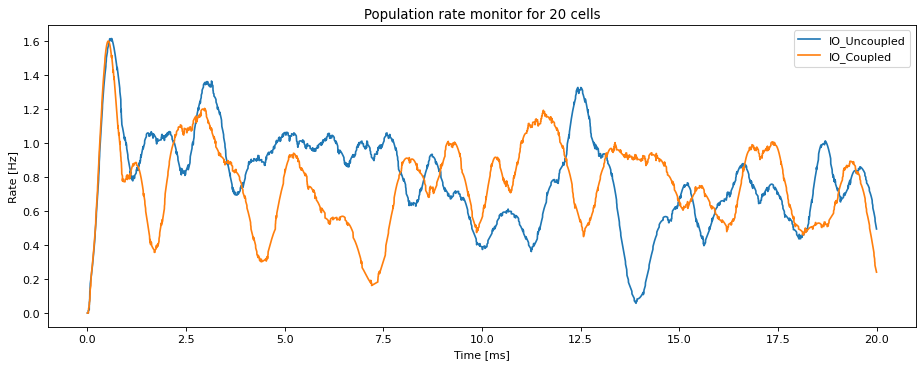

In [12]:
width = 200*ms
plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
plot(IO_rate.t, IO_rate.smooth_rate(window='gaussian', width=width)/Hz, label='IO_Uncoupled')
plot(IO_rate_Coupled.t, IO_rate_Coupled.smooth_rate(window='gaussian', width=width)/Hz, label='IO_Coupled')
title('Population rate monitor for '+str(N_Cells_IO)+" cells")
ylabel('Rate [Hz]')
xlabel('Time [ms]')
legend()
show()

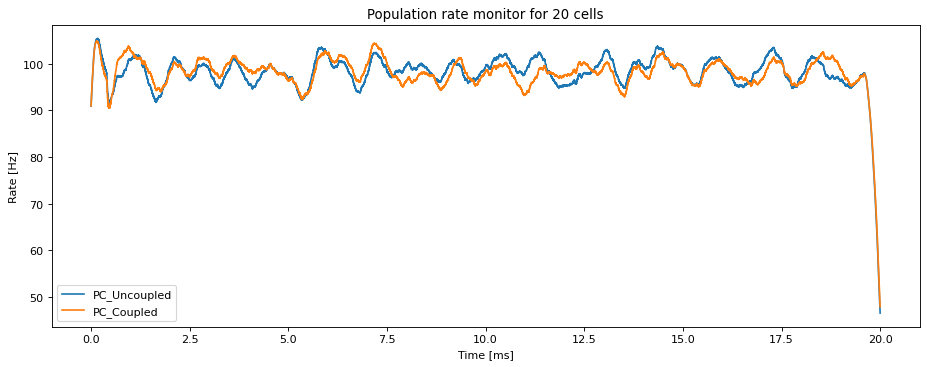

In [5]:
plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
plot(PC_rate.t, PC_rate.smooth_rate(window='gaussian', width=width)/Hz, label='PC_Uncoupled')
plot(PC_rate_Coupled.t, PC_rate_Coupled.smooth_rate(window='gaussian', width=width)/Hz, label='PC_Coupled')
title('Population rate monitor for '+str(N_Cells_IO)+" cells")
ylabel('Rate [Hz]')
xlabel('Time [ms]')
legend()
show()

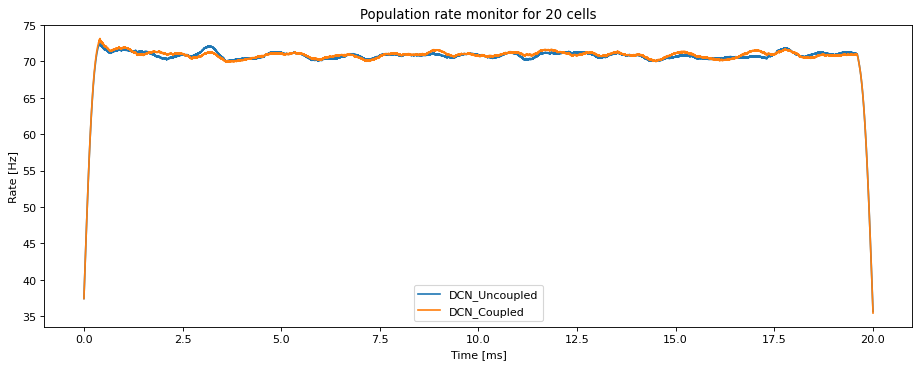

In [6]:
plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
plot(DCN_rate.t, DCN_rate.smooth_rate(window='gaussian', width=width)/Hz, label='DCN_Uncoupled')
plot(DCN_rate_Coupled.t, DCN_rate_Coupled.smooth_rate(window='gaussian', width=width)/Hz, label='DCN_Coupled')
title('Population rate monitor for '+str(N_Cells_IO)+" cells")
ylabel('Rate [Hz]')
xlabel('Time [ms]')
legend()
show()

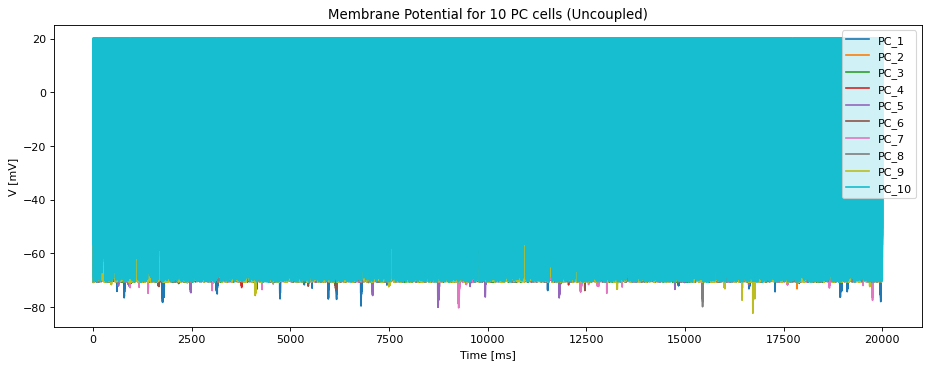

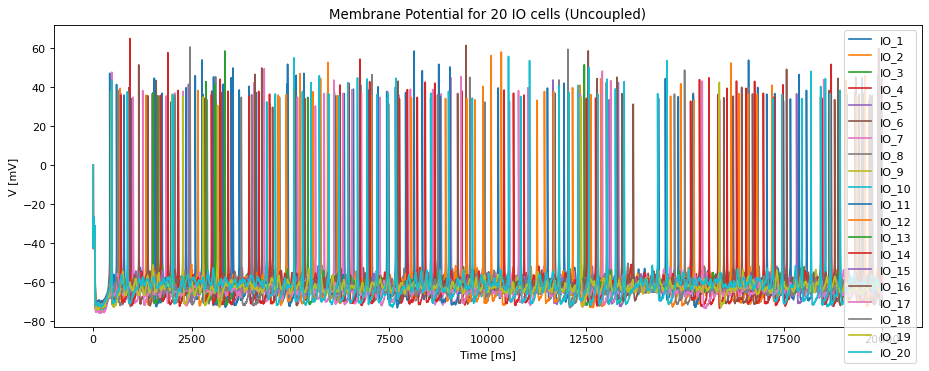

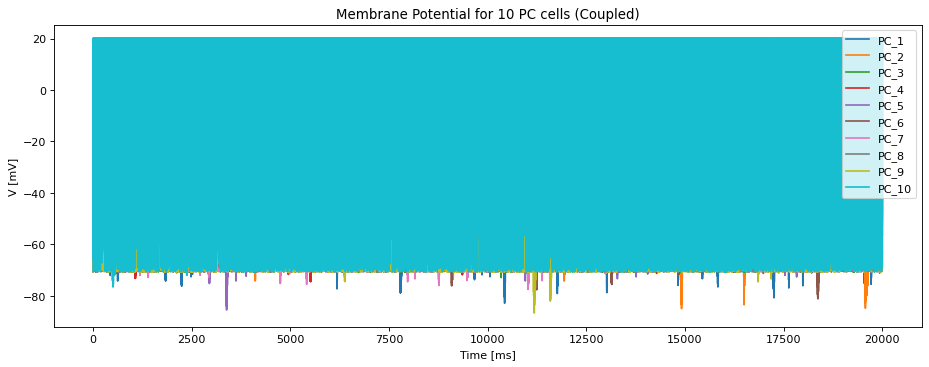

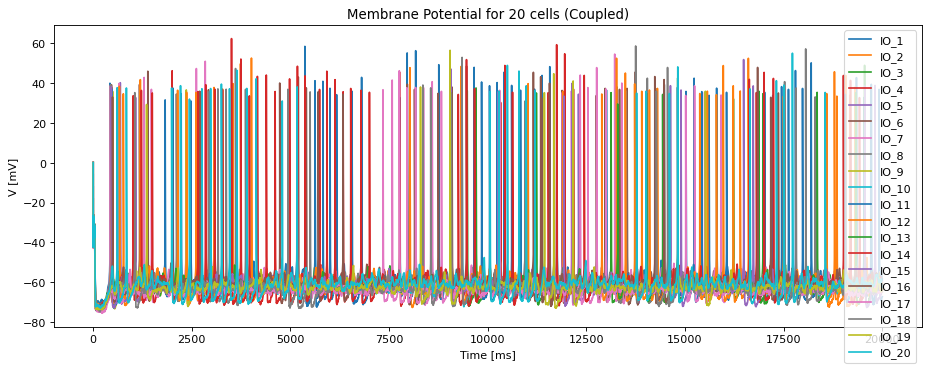

CPU times: user 27.6 s, sys: 510 ms, total: 28.1 s
Wall time: 28.5 s


In [7]:
%%time
plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
for ii in range(0,N_Cells_PC):
    vm = PC_Statemon[ii].v[:]
    for t in PC_Spikemon.t:
        i = int(t / dt_rec)
        vm[i] = 20*mV
    plot(PC_Statemon.t/ms,vm/mV, label='PC_'+str(ii+1))
title('Membrane Potential for '+str(N_Cells_PC)+" PC cells (Uncoupled)")
ylabel('V [mV]')
xlabel('Time [ms]')
legend()
show()

plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
for ii in range(0,N_Cells_IO):
    plot(IO_Statemon.t/ms,IO_Statemon.Vs[ii]/mV, label='IO_'+str(ii+1))
title('Membrane Potential for '+str(N_Cells_IO)+" IO cells (Uncoupled)")
ylabel('V [mV]')
xlabel('Time [ms]')
legend()
show()

plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
for ii in range(0,N_Cells_PC):
    vm_Coupled = PC_Statemon_Coupled[ii].v[:]
    for t in PC_Spikemon_Coupled.t:
        i = int(t / dt_rec)
        vm_Coupled[i] = 20*mV
    plot(PC_Statemon_Coupled.t/ms,vm_Coupled/mV, label='PC_'+str(ii+1))
title('Membrane Potential for '+str(N_Cells_PC)+" PC cells (Coupled)")
ylabel('V [mV]')
xlabel('Time [ms]')
legend()
show()

plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
for ii in range(0,N_Cells_IO):
    plot(IO_Statemon_Coupled.t/ms,IO_Statemon_Coupled.Vs[ii]/mV, label='IO_'+str(ii+1))
title('Membrane Potential for '+str(N_Cells_IO)+" cells (Coupled)")
ylabel('V [mV]')
xlabel('Time [ms]')
legend()
show()

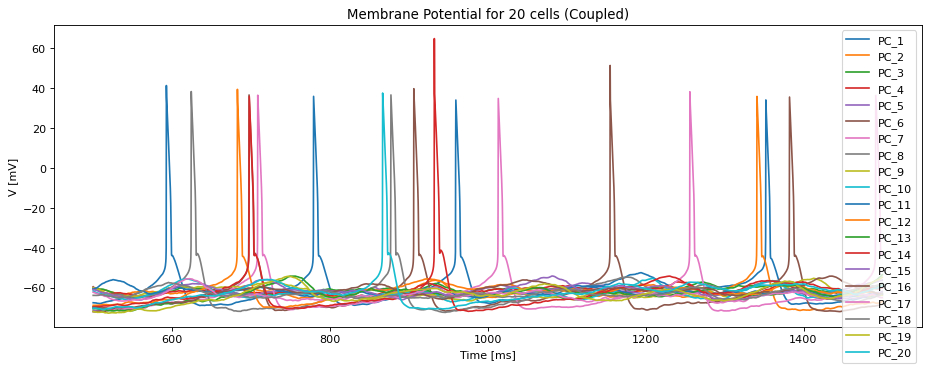

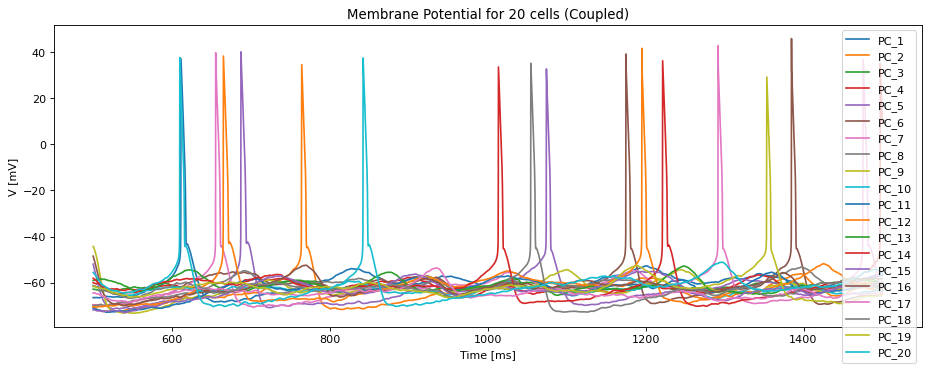

In [8]:
start = 2000
end = 6000
plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
for ii in range(0,N_Cells_IO):
    plot(IO_Statemon.t[start:end]/ms,IO_Statemon.Vs[ii][start:end]/mV, label='PC_'+str(ii+1))
title('Membrane Potential for '+str(N_Cells_IO)+" cells (Coupled)")
ylabel('V [mV]')
xlabel('Time [ms]')
legend()
show()

plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
for ii in range(0,N_Cells_IO):
    plot(IO_Statemon_Coupled.t[start:end]/ms,IO_Statemon_Coupled.Vs[ii][start:end]/mV, label='PC_'+str(ii+1))
title('Membrane Potential for '+str(N_Cells_IO)+" cells (Coupled)")
ylabel('V [mV]')
xlabel('Time [ms]')
legend()
show()

In [9]:
%%time
Create_output("_New_BCM",width,Noise_statemon,Noise_extended_statemon,PC_Statemon,PC_Spikemon, PC_rate,DCN_Statemon,DCN_Spikemon, DCN_rate,IO_Statemon,IO_Spikemon,IO_rate,mon_N_PC,Noise_statemon_Coupled,Noise_extended_statemon_Coupled,PC_Statemon_Coupled,PC_Spikemon_Coupled, PC_rate_Coupled,DCN_Statemon_Coupled,DCN_Spikemon_Coupled,DCN_rate_Coupled,IO_Statemon_Coupled,IO_Spikemon_Coupled,IO_rate_Coupled,mon_N_PC_Coupled)

WARNING    /Users/eliasmateofernandezsantoro/Python/miniconda3/lib/python3.8/site-packages/numpy/core/_asarray.py:136: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  return array(a, dtype, copy=False, order=order, subok=True)
 [py.warnings]
  return array(a, dtype, copy=False, order=order, subok=True)



CPU times: user 1min 29s, sys: 1.56 s, total: 1min 31s
Wall time: 12.6 s
